# Análise de dados da estação de monitoramento da LI-COR Eddy Covariance em Nebraska 2013

A partir do dataset disponibilizado publicamente no website da LI-COR, podemos fazer a importação e transforma-lo em um DataFrame com o pandas:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("eddypro.csv", low_memory=False, skiprows=1)

In [2]:
df.shape

(17520, 198)

Temos um dataset que conta com 17520 linhas e 198 colunas 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Columns: 198 entries, filename to BoardWatts_mean
dtypes: str(198)
memory usage: 26.5 MB


Aparentemente, pouquissima memoria é consumida para retirar as informações do dataset, oque indica que o python pode ser uma ferramenta de trabalho ate que aceitável para fazer a análise dos dados obtidos por meio do Método Eddy Covariance sem precisar depender do ecossistema da LI-COR, e sim apenas com Pandas.

Em um primeiro momento, selecionamos apenas 10 medições para ter uma noção de comos nossos valores estão relacionados ao passar do tempo. Cada linha é dividia em um intervalo de 30 minutos, o que nos indica que temos valores captados nesse mesmo intervalo, e assim, até completar um ano de 365 dias.

In [4]:
df.head(10)

,filename,date,time,DOY,daytime,file_records,used_records,Tau,qc_Tau,rand_err_Tau,...,FlowP_mean,FlowPow_mean,FlowDr_mean,H2OSamp_mean,H2ORef_mean,CO2Samp_mean,CO2Ref_mean,TubeTemp_mean,BoardTemp_mean,BoardWatts_mean
0,NaN,[yyyy-mm-dd],[HH:MM],[ddd.ddd],[1=daytime],[#],[#],[kg+1m-1s-2],[#],[kg+1m-1s-2],...,--,--,--,--,--,--,--,--,--,--
1,2013-01-01T000000_LERS-72H-0181.txt,2013-01-01,00:30,1020,0,18000,18000,4.3920675758044675E-002,0,4.9911606956409621E-003,...,0.94482731634378392,5.6254436695045884,26.897538821220401,36479.223277777775,39119.411694444447,26949.089666666667,29058.063138888891,-9999.0,-9999.0,-9999.0
2,2013-01-01T003000_LERS-72H-0181.txt,2013-01-01,01:00,1041,0,18000,18000,3.3044566251049741E-002,0,4.6602942508831187E-003,...,0.93896759260363072,5.6077253089745840,26.813649940808613,36493.074333333330,39124.409583333334,26942.204078971066,29061.210083333332,-9999.0,-9999.0,-9999.0
3,2013-01-01T010000_LERS-72H-0181.txt,2013-01-01,01:30,1062,0,18000,18000,5.2370511926666655E-002,0,8.2455683359258809E-003,...,0.93975608683294731,5.6108060949113634,26.816188806851709,36501.808833333336,39128.018944444448,26926.889055555555,29064.303638888890,-9999.0,-9999.0,-9999.0
4,2013-01-01T013000_LERS-72H-0181.txt,2013-01-01,02:00,1083,0,18000,18000,5.4466107545444994E-002,0,6.8254179029892227E-003,...,0.94026127651002667,5.6165730587906308,26.851233254008825,36531.713277777781,39141.154916666666,26933.691761419213,29073.089388888890,-9999.0,-9999.0,-9999.0
5,2013-01-01T020000_LERS-72H-0181.txt,2013-01-01,02:30,1104,0,18000,18000,4.6572787264948207E-002,0,5.9014006236778648E-003,...,0.93690190741088641,5.6091122144858039,26.834761015892028,36575.404480003519,39162.827361111114,26945.746666666666,29089.437388888888,-9999.0,-9999.0,-9999.0
6,2013-01-01T023000_LERS-72H-0181.txt,2013-01-01,03:00,1124,0,18000,18000,3.6994851106176514E-002,0,4.9492678040859240E-003,...,0.93651540572775749,5.6065712248219395,26.839244386778937,36610.158611111110,39180.128888888888,26951.392333333333,29102.657972222223,-9999.0,-9999.0,-9999.0
7,2013-01-01T030000_LERS-72H-0181.txt,2013-01-01,03:30,1145,0,18000,18000,2.5789380168964034E-002,0,4.5040420413645877E-003,...,0.93432672904266256,5.6037676404317214,26.802699894481236,36648.465777777776,39199.133944444446,26953.669111111110,29117.308194444446,-9999.0,-9999.0,-9999.0
8,2013-01-01T033000_LERS-72H-0181.txt,2013-01-01,04:00,1166,0,18000,18000,1.3336342647789830E-002,0,2.2038669445929035E-003,...,0.92915122145083229,5.5918248799377004,26.744838921440962,36673.187833333330,39210.126416666666,26941.869333333332,29125.649555555556,-9999.0,-9999.0,-9999.0
9,2013-01-01T040000_LERS-72H-0181.txt,2013-01-01,04:30,1187,0,18000,18000,7.2247230457937852E-003,0,1.1241188117704021E-003,...,0.92212559874190225,5.5717007779810173,26.618133428997467,36683.629833333332,39210.865277777775,26934.647833333333,29125.154666666665,-9999.0,-9999.0,-9999.0


## Verificamos então quais são as colunas presentes no nosso dataset:

In [5]:
list(df.columns)

['filename',
 'date',
 'time',
 'DOY',
 'daytime',
 'file_records',
 'used_records',
 'Tau',
 'qc_Tau',
 'rand_err_Tau',
 'H',
 'qc_H',
 'rand_err_H',
 'LE',
 'qc_LE',
 'rand_err_LE',
 'co2_flux',
 'qc_co2_flux',
 'rand_err_co2_flux',
 'h2o_flux',
 'qc_h2o_flux',
 'rand_err_h2o_flux',
 'ch4_flux',
 'qc_ch4_flux',
 'rand_err_ch4_flux',
 'none_flux',
 'qc_none_flux',
 'rand_err_none_flux',
 'H_strg',
 'LE_strg',
 'co2_strg',
 'h2o_strg',
 'ch4_strg',
 'none_strg',
 'co2_v-adv',
 'h2o_v-adv',
 'ch4_v-adv',
 'none_v-adv',
 'co2_molar_density',
 'co2_mole_fraction',
 'co2_mixing_ratio',
 'co2_time_lag',
 'co2_def_timelag',
 'h2o_molar_density',
 'h2o_mole_fraction',
 'h2o_mixing_ratio',
 'h2o_time_lag',
 'h2o_def_timelag',
 'ch4_molar_density',
 'ch4_mole_fraction',
 'ch4_mixing_ratio',
 'ch4_time_lag',
 'ch4_def_timelag',
 'none_molar_density',
 'none_mole_fraction',
 'none_mixing_ratio',
 'none_time_lag',
 'none_def_timelag',
 'sonic_temperature',
 'air_temperature',
 'air_pressure',
 'ai

Neste primeiro momento, precisamos nos preocupar em quais colunas queremos filtrar. Abaixo seguem algumas perguntas o qual nossos dados podem responder:

1. Como o fluxo de $CO_2$ se comporta como uma função do tempo, e quais são as características de sua periodicidade ao longo do ciclo diário de 24 horas?
2. Qual é a taxa de variação do fluxo de calor latente em resposta ao aumento da radiação solar durante o período das 05:00 às 09:00 da manhã?
3. Qual é a diferença na capacidade média de retenção de carbono do ecossistema em dias de temperatura extrema (acima do 90º percentil) em comparação com os dias de temperatura amena?

Filtramos as colunas que serão necessárias na resposta da primeira pergunta.

In [6]:
colunas_q1 = ['date', 'time',  'co2_flux',  'qc_co2_flux',]
df_q1 = df[colunas_q1].copy()
df_q1.info()

<class 'pandas.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         17520 non-null  str  
 1   time         17520 non-null  str  
 2   co2_flux     17520 non-null  str  
 3   qc_co2_flux  17520 non-null  str  
dtypes: str(4)
memory usage: 547.6 KB


Vale notar que todos os valores presentes são do tipo str(), precisamos converte-los para tipo float()

In [7]:
df_q1 = df_q1.drop(0) 
df_q1['co2_flux'] = pd.to_numeric(df_q1['co2_flux'])
df_q1['qc_co2_flux'] = pd.to_numeric(df_q1['qc_co2_flux'])

Façamos então a visualização da nossa nova tabela de valores:

In [8]:
df_q1['co2_flux'] = df_q1['co2_flux'].replace(-9999.0, np.nan)
df_q1['qc_co2_flux'] = df_q1['qc_co2_flux'].replace(-9999.0, np.nan)
df_q1.loc[df_q1['qc_co2_flux'] == 2.0, 'qc_co2_flux'] = np.nan

df_q1.head(20)

,date,time,co2_flux,qc_co2_flux
1,2013-01-01,00:30,1.953302,0.0
2,2013-01-01,01:00,1.854615,1.0
3,2013-01-01,01:30,2.383073,0.0
4,2013-01-01,02:00,2.591592,0.0
5,2013-01-01,02:30,1.895338,0.0
6,2013-01-01,03:00,2.670981,0.0
7,2013-01-01,03:30,3.313939,0.0
8,2013-01-01,04:00,3.260366,0.0
9,2013-01-01,04:30,1.427305,0.0
10,2013-01-01,05:00,3.110685,0.0


In [9]:
df_q1.describe

<bound method NDFrame.describe of              date   time  co2_flux  qc_co2_flux
1      2013-01-01  00:30  1.953302          0.0
2      2013-01-01  01:00  1.854615          1.0
3      2013-01-01  01:30  2.383073          0.0
4      2013-01-01  02:00  2.591592          0.0
5      2013-01-01  02:30  1.895338          0.0
...           ...    ...       ...          ...
17515  2013-12-31  21:30  6.858085          0.0
17516  2013-12-31  22:00  6.972829          0.0
17517  2013-12-31  22:30  3.639357          0.0
17518  2013-12-31  23:00  5.839417          0.0
17519  2013-12-31  23:30  6.067702          0.0

[17519 rows x 4 columns]>

Podemos então fazer a visualização do ciclo diário médio do fluxo de $CO_2$

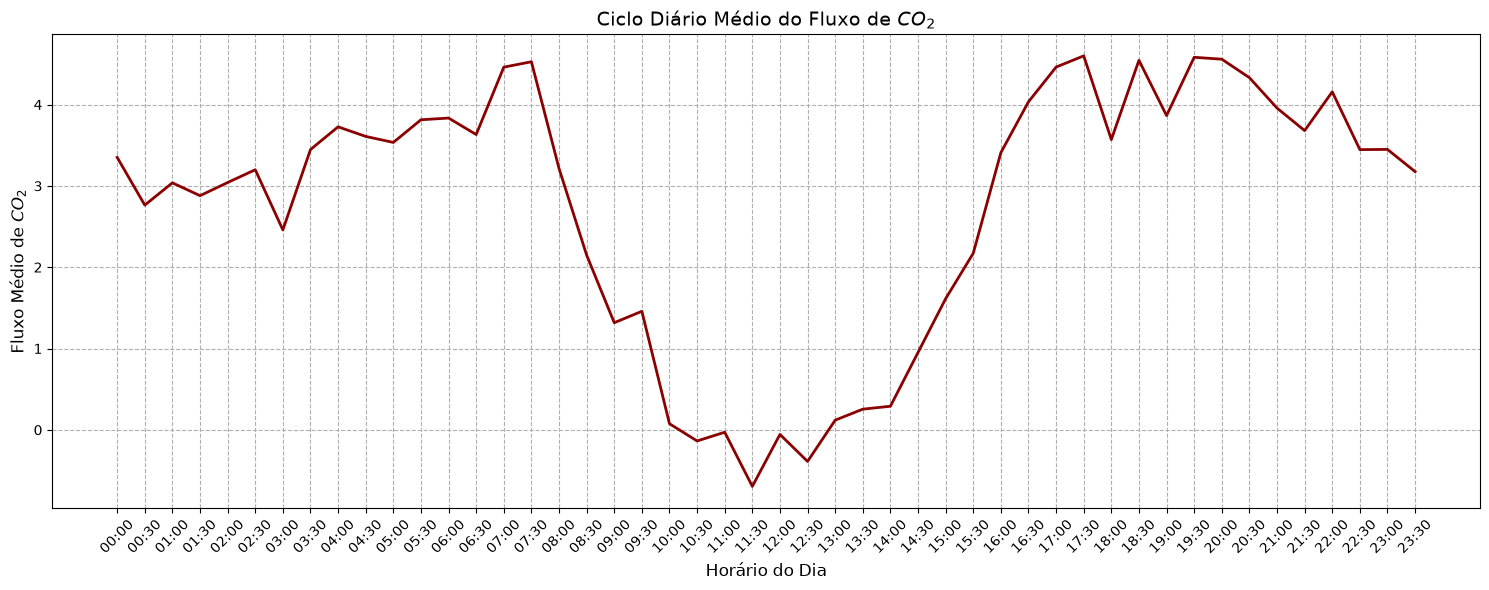

In [10]:
# 1. Calculamos o ciclo médio diário usando o agrupamento
ciclo_medio = df_q1.groupby('time')['co2_flux'].mean()

# 2. Preparamos a nova tela
fig, ax = plt.subplots(figsize=(15, 6))

# 3. Plotamos a função f(t) como uma linha contínua
ax.plot(ciclo_medio.index, ciclo_medio.values, color='darkred', linewidth=2)

ax.set_xlabel('Horário do Dia', fontsize=12)
ax.set_ylabel(r'Fluxo Médio de $CO_2$', fontsize=12)
ax.set_title(r'Ciclo Diário Médio do Fluxo de $CO_2$', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=1)
fig.tight_layout()
plt.savefig('ciclo_co2.png', dpi=150, bbox_inches="tight")

plt.show()